In [63]:
import pandas as pd

df = pd.read_csv("student_placement_10k.csv")

df.head()

,cgpa,backlog_count,degree_branch,internship_count,internship_duration_months,project_count,project_complexity_score,certification_count,skill_diversity_score,github_contributions,github_repo_count,leetcode_problems_solved,leetcode_contest_rating,placement_score,company_tier,placed
0,6.56,0,ECE,0,0,2,3.72,3,4.07,0,0,96,1454,27.69,Not Placed,0
1,6.93,0,EEE,3,10,0,0.00,3,4.71,1017,3,0,0,42.71,Mass Recruiter,1
2,8.55,0,CS,2,10,5,5.86,1,6.32,625,29,268,1342,63.14,Mid-tier,1
3,7.15,1,CS,0,0,5,4.51,2,5.15,580,17,220,1413,45.42,Mass Recruiter,1
4,6.03,1,CS,1,4,3,2.14,4,4.98,665,17,105,1535,41.55,Mass Recruiter,1


In [64]:
df.shape
df.info()
df.describe().round(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cgpa                        10000 non-null  float64
 1   backlog_count               10000 non-null  int64  
 2   degree_branch               10000 non-null  object 
 3   internship_count            10000 non-null  int64  
 4   internship_duration_months  10000 non-null  int64  
 5   project_count               10000 non-null  int64  
 6   project_complexity_score    10000 non-null  float64
 7   certification_count         10000 non-null  int64  
 8   skill_diversity_score       10000 non-null  float64
 9   github_contributions        10000 non-null  int64  
 10  github_repo_count           10000 non-null  int64  
 11  leetcode_problems_solved    10000 non-null  int64  
 12  leetcode_contest_rating     10000 non-null  int64  
 13  placement_score             1000

,cgpa,backlog_count,internship_count,internship_duration_months,project_count,project_complexity_score,certification_count,skill_diversity_score,github_contributions,github_repo_count,leetcode_problems_solved,leetcode_contest_rating,placement_score,placed
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,7.09,0.91,0.86,2.73,2.71,3.17,2.54,4.46,309.21,16.59,121.43,984.07,36.56,0.53
std,1.01,1.23,1.01,3.42,1.57,1.76,1.70,1.54,279.00,14.81,135.20,747.37,17.25,0.50
min,5.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,-11.58,0.00
25%,6.30,0.00,0.00,0.00,2.00,1.99,1.00,3.33,0.00,0.00,0.00,0.00,23.79,0.00
50%,7.02,0.00,1.00,2.00,3.00,3.23,2.00,4.58,301.00,16.00,92.00,1358.00,36.22,1.00
75%,7.79,2.00,1.00,4.00,4.00,4.38,4.00,5.60,544.00,29.00,200.25,1560.00,48.62,1.00
max,9.90,6.00,4.00,18.00,7.00,9.12,12.00,9.11,1289.00,71.00,841.00,2528.00,95.76,1.00


In [65]:
df.isnull().sum()

cgpa                          0
backlog_count                 0
degree_branch                 0
internship_count              0
internship_duration_months    0
project_count                 0
project_complexity_score      0
certification_count           0
skill_diversity_score         0
github_contributions          0
github_repo_count             0
leetcode_problems_solved      0
leetcode_contest_rating       0
placement_score               0
company_tier                  0
placed                        0
dtype: int64

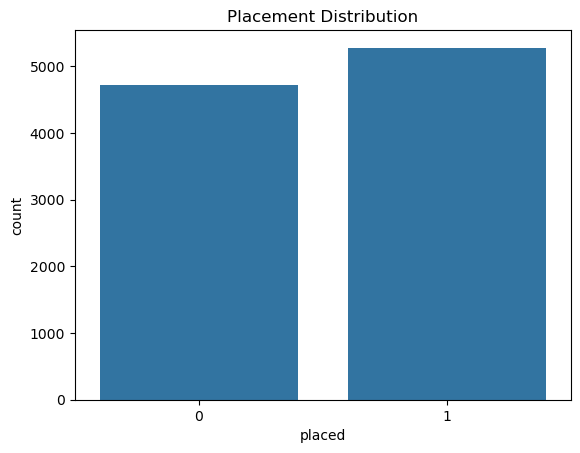

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="placed", data=df)
plt.title("Placement Distribution")
plt.show()

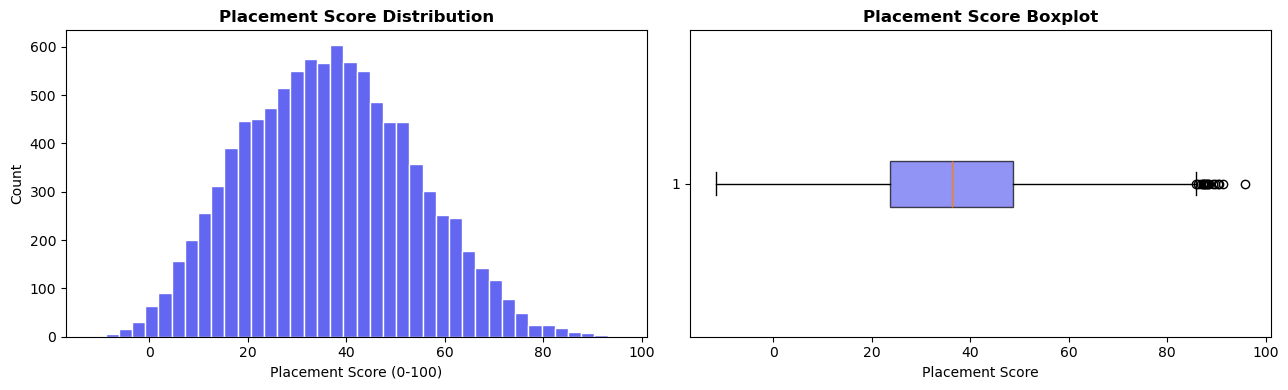

Mean   : 36.56
Median : 36.22
Std    : 17.25
Min    : -11.58
Max    : 95.76


In [67]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(df['placement_score'], bins=40, color='#6366f1', edgecolor='white')
axes[0].set_title('Placement Score Distribution', fontweight='bold')
axes[0].set_xlabel('Placement Score (0-100)')
axes[0].set_ylabel('Count')

# Boxplot
axes[1].boxplot(df['placement_score'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#6366f1', alpha=0.7))
axes[1].set_title('Placement Score Boxplot', fontweight='bold')
axes[1].set_xlabel('Placement Score')

plt.tight_layout()
plt.show()

print(f"Mean   : {df['placement_score'].mean():.2f}")
print(f"Median : {df['placement_score'].median():.2f}")
print(f"Std    : {df['placement_score'].std():.2f}")
print(f"Min    : {df['placement_score'].min():.2f}")
print(f"Max    : {df['placement_score'].max():.2f}")

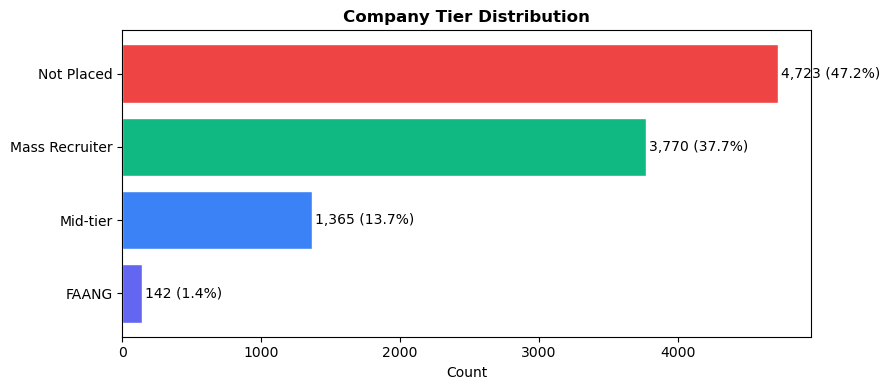

In [68]:
tier_order  = ['FAANG', 'Mid-tier', 'Mass Recruiter', 'Not Placed']
tier_colors = ['#6366f1', '#3b82f6', '#10b981', '#ef4444']

tier_counts = df['company_tier'].value_counts().reindex(tier_order)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(tier_order, tier_counts.values, color=tier_colors, edgecolor='white')
ax.set_title('Company Tier Distribution', fontweight='bold')
ax.set_xlabel('Count')
for bar, val in zip(bars, tier_counts.values):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({val/len(df)*100:.1f}%)', va='center')
plt.tight_layout()
plt.show()

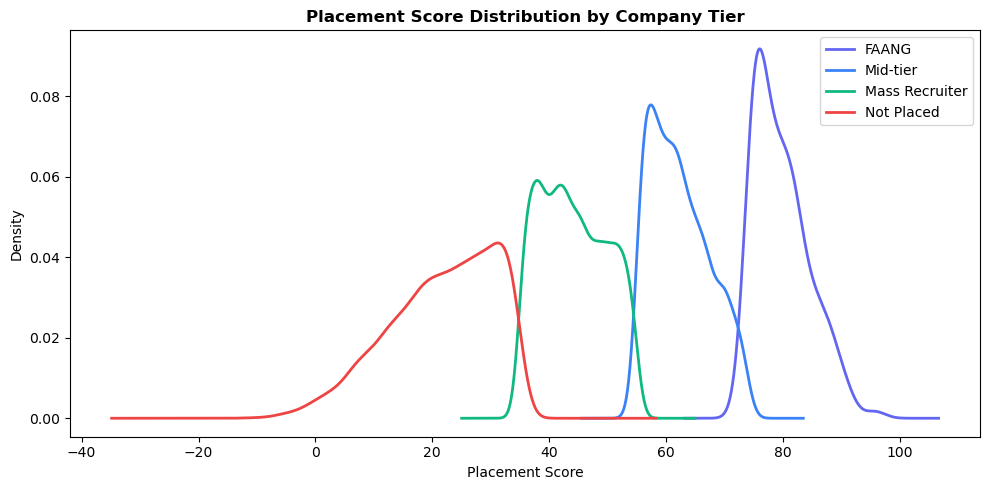

In [70]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = {'FAANG': '#6366f1', 'Mid-tier': '#3b82f6',
          'Mass Recruiter': '#10b981', 'Not Placed': '#ef4444'}

for tier in tier_order:
    data = df[df['company_tier'] == tier]['placement_score']
    data.plot(kind='kde', ax=ax, label=tier,
              color=colors[tier], linewidth=2)

ax.set_title('Placement Score Distribution by Company Tier', fontweight='bold')
ax.set_xlabel('Placement Score')
ax.legend()
plt.tight_layout()
plt.show()

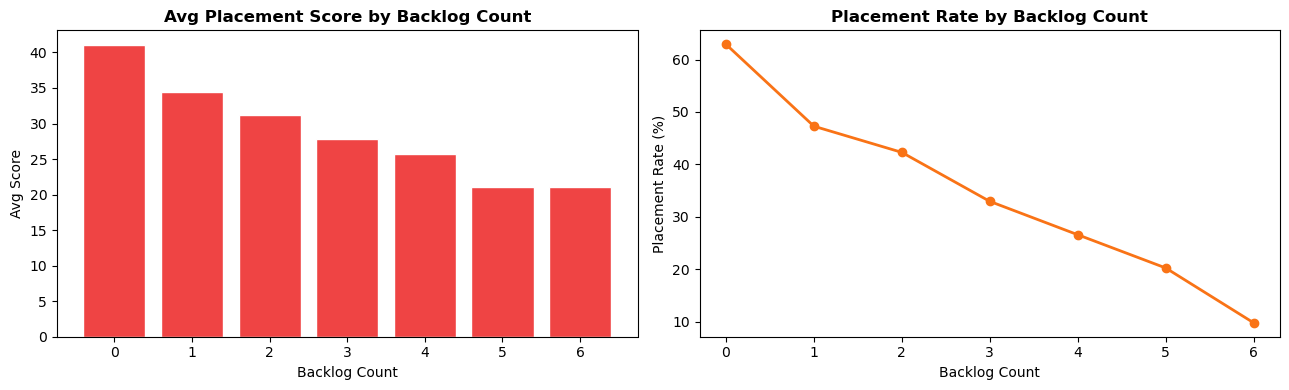

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Average score by backlog count
avg_backlog = df.groupby('backlog_count')['placement_score'].mean()
axes[0].bar(avg_backlog.index, avg_backlog.values, color='#ef4444', edgecolor='white')
axes[0].set_title('Avg Placement Score by Backlog Count', fontweight='bold')
axes[0].set_xlabel('Backlog Count')
axes[0].set_ylabel('Avg Score')

# Placement rate by backlog
rate = df.groupby('backlog_count')['placed'].mean() * 100
axes[1].plot(rate.index, rate.values, color='#f97316',
             marker='o', linewidth=2)
axes[1].set_title('Placement Rate by Backlog Count', fontweight='bold')
axes[1].set_xlabel('Backlog Count')
axes[1].set_ylabel('Placement Rate (%)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_495762/1840761071.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg = df.groupby('cgpa_bucket')['placement_score'].mean()


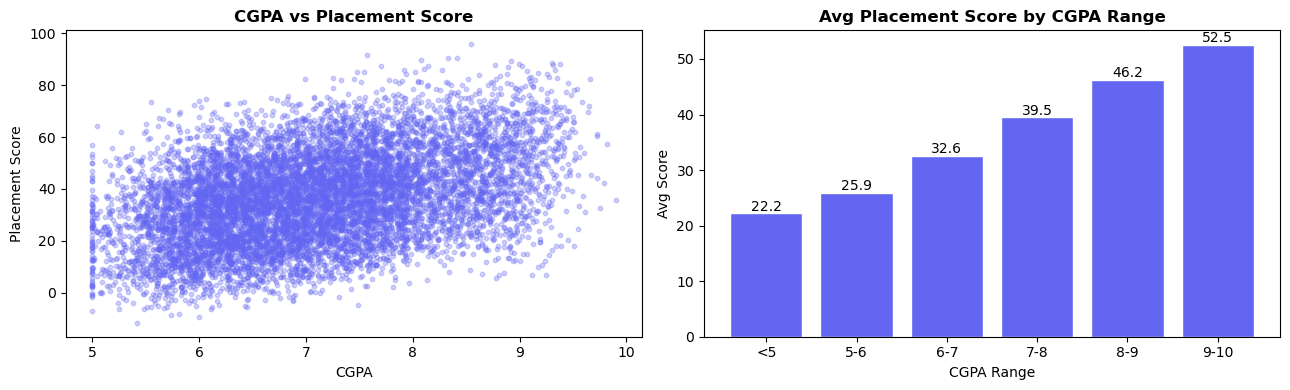

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatter
axes[0].scatter(df['cgpa'], df['placement_score'],
                alpha=0.3, color='#6366f1', s=10)
axes[0].set_xlabel('CGPA')
axes[0].set_ylabel('Placement Score')
axes[0].set_title('CGPA vs Placement Score', fontweight='bold')

# Average score by CGPA bucket
df['cgpa_bucket'] = pd.cut(df['cgpa'], bins=[0,5,6,7,8,9,10],
                           labels=['<5','5-6','6-7','7-8','8-9','9-10'])
avg = df.groupby('cgpa_bucket')['placement_score'].mean()
axes[1].bar(avg.index, avg.values, color='#6366f1', edgecolor='white')
axes[1].set_title('Avg Placement Score by CGPA Range', fontweight='bold')
axes[1].set_xlabel('CGPA Range')
axes[1].set_ylabel('Avg Score')
for i, v in enumerate(avg.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center')

plt.tight_layout()
plt.show()

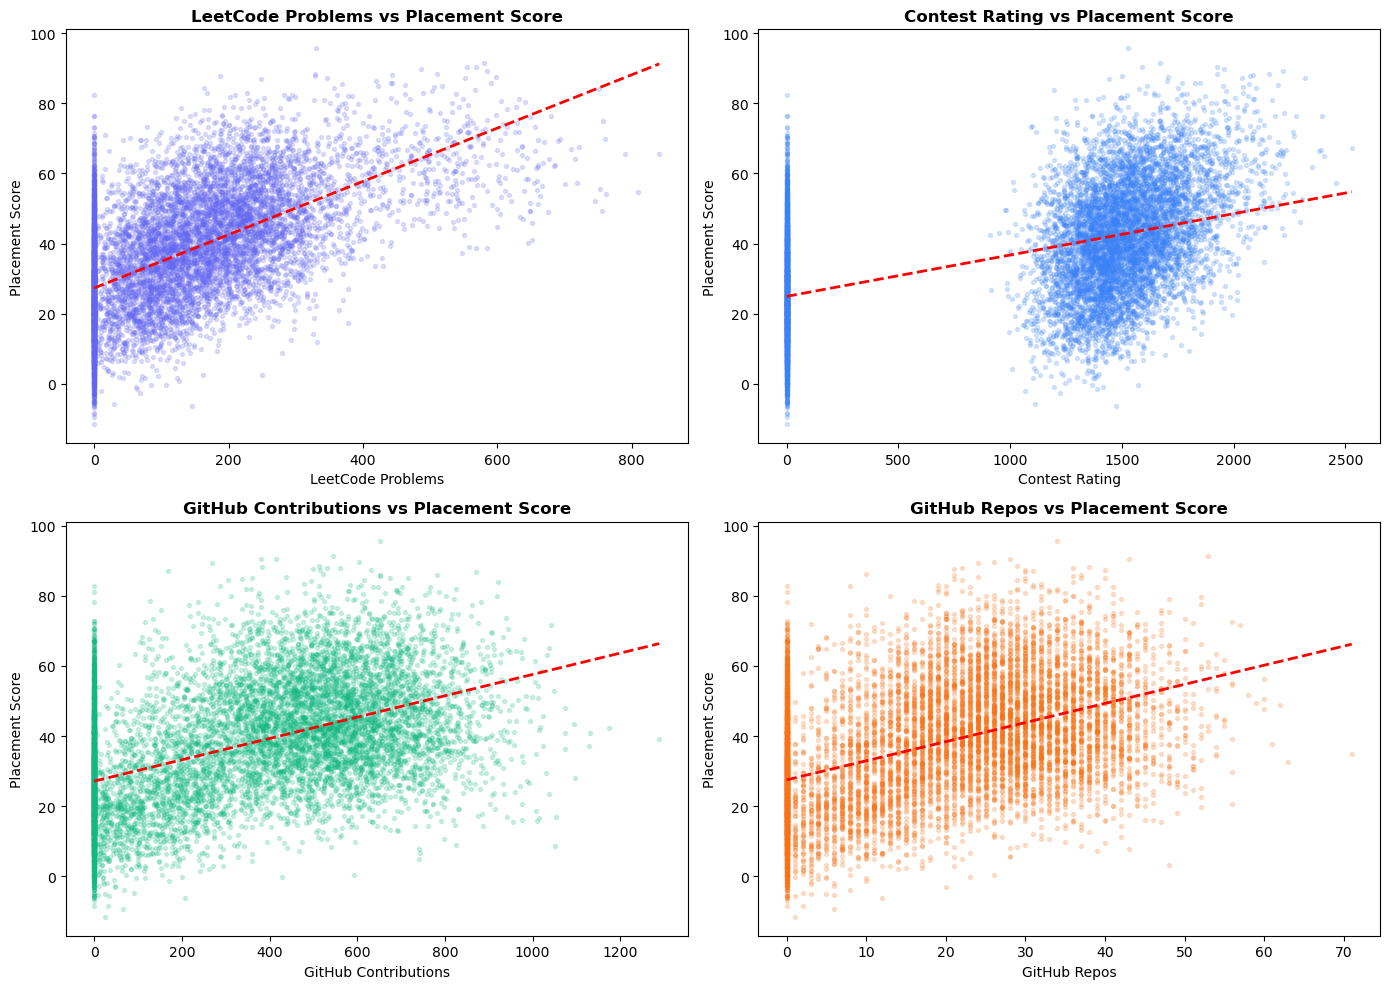

In [74]:
import numpy as np
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pairs = [
    ('leetcode_problems_solved', 'placement_score', '#6366f1', 'LeetCode Problems'),
    ('leetcode_contest_rating',  'placement_score', '#3b82f6', 'Contest Rating'),
    ('github_contributions',     'placement_score', '#10b981', 'GitHub Contributions'),
    ('github_repo_count',        'placement_score', '#f97316', 'GitHub Repos'),
]

for ax, (x, y, color, title) in zip(axes.flatten(), pairs):
    ax.scatter(df[x], df[y], alpha=0.2, color=color, s=8)
    # trend line
    z = np.polyfit(df[x], df[y], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[x].min(), df[x].max(), 100)
    ax.plot(x_line, p(x_line), color='red', linewidth=2, linestyle='--')
    ax.set_xlabel(title)
    ax.set_ylabel('Placement Score')
    ax.set_title(f'{title} vs Placement Score', fontweight='bold')

plt.tight_layout()
plt.show()

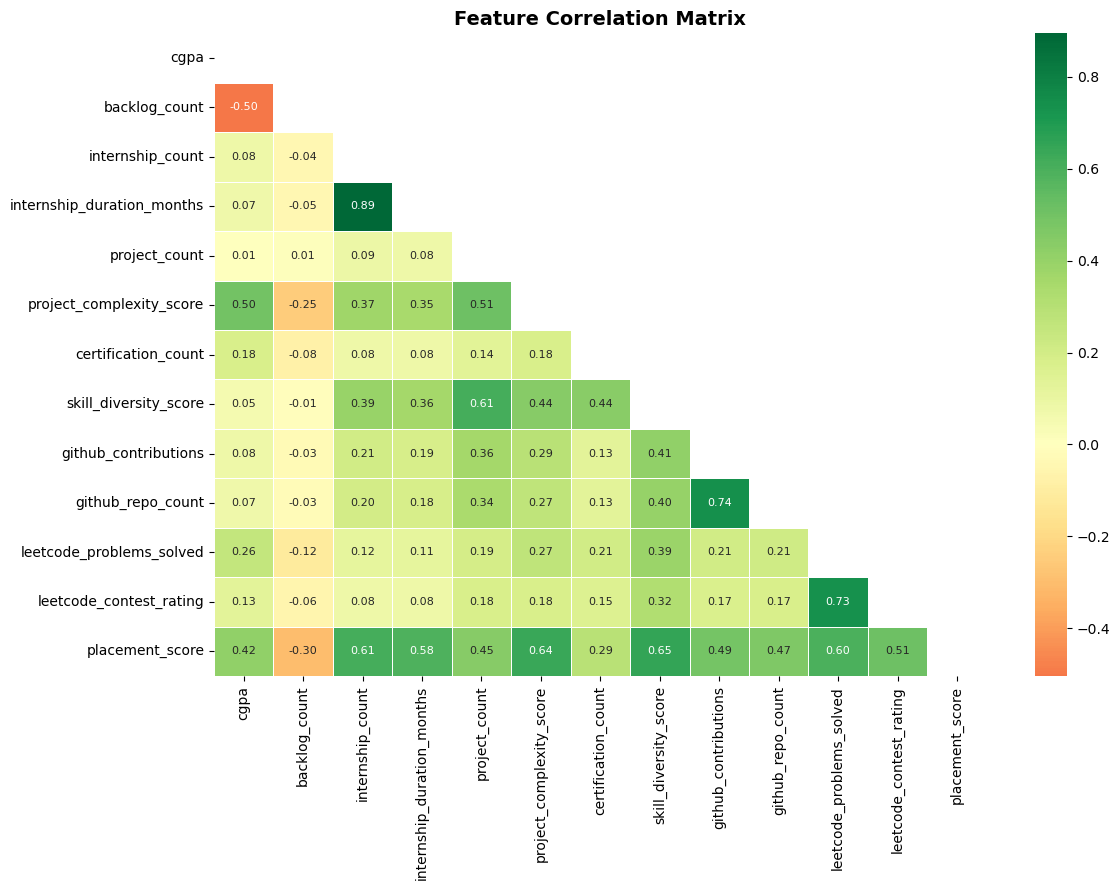

In [75]:
num_cols = [
    'cgpa', 'backlog_count', 'internship_count',
    'internship_duration_months', 'project_count',
    'project_complexity_score', 'certification_count',
    'skill_diversity_score', 'github_contributions',
    'github_repo_count', 'leetcode_problems_solved',
    'leetcode_contest_rating', 'placement_score'
]

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

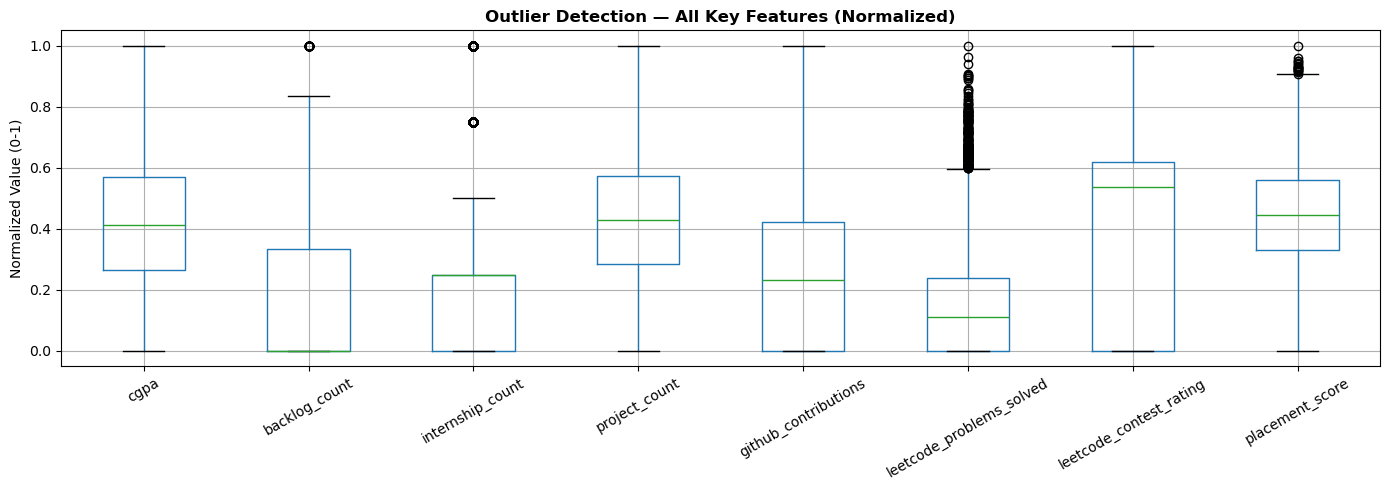

In [76]:
fig, ax = plt.subplots(figsize=(14, 5))

key_features = [
    'cgpa', 'backlog_count', 'internship_count',
    'project_count', 'github_contributions',
    'leetcode_problems_solved', 'leetcode_contest_rating',
    'placement_score'
]

# Normalize to same scale for boxplot
from sklearn.preprocessing import MinMaxScaler
temp = MinMaxScaler().fit_transform(df[key_features])
temp_df = pd.DataFrame(temp, columns=key_features)

temp_df.boxplot(ax=ax, rot=30)
ax.set_title('Outlier Detection — All Key Features (Normalized)', fontweight='bold')
ax.set_ylabel('Normalized Value (0-1)')
plt.tight_layout()
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'ECE'),
  Text(1, 0, 'EEE'),
  Text(2, 0, 'CS'),
  Text(3, 0, 'IT'),
  Text(4, 0, 'Mechanical'),
  Text(5, 0, 'Chemical'),
  Text(6, 0, 'Civil'),
  Text(7, 0, 'Biotech')])

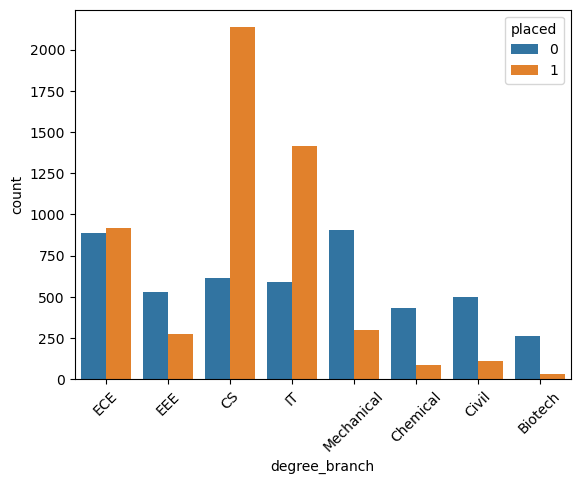

In [5]:
sns.countplot(x="degree_branch", hue="placed", data=df)
plt.xticks(rotation=45)

<Axes: xlabel='placed', ylabel='cgpa'>

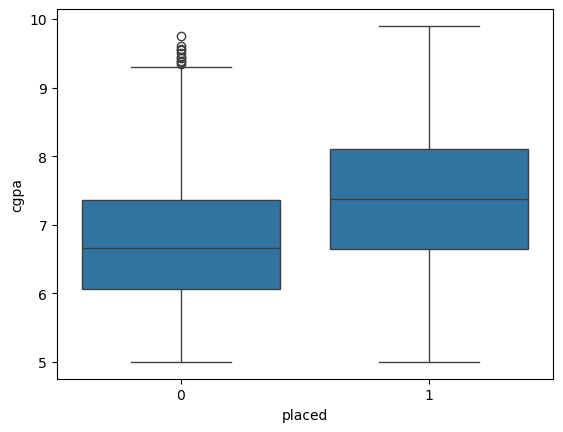

In [6]:

sns.boxplot(x="placed", y="cgpa", data=df)

<Axes: xlabel='leetcode_problems_solved', ylabel='placement_score'>

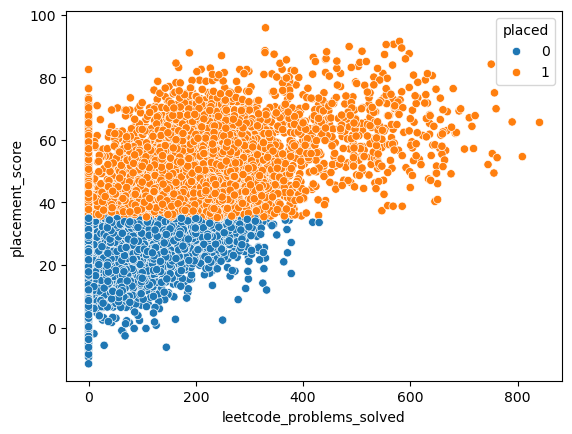

In [7]:
sns.scatterplot(x="leetcode_problems_solved", y="placement_score", hue="placed", data=df)

<Axes: xlabel='placed', ylabel='internship_count'>

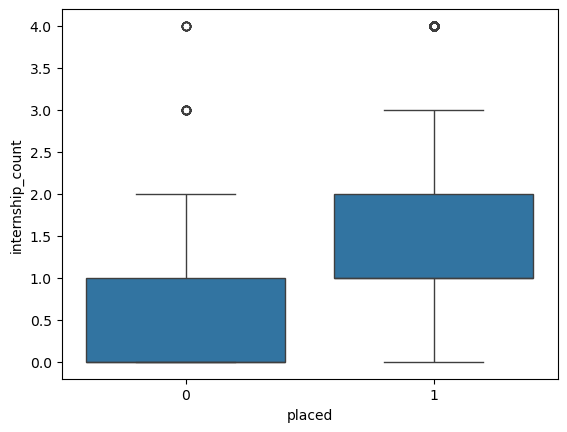

In [8]:
sns.boxplot(x="placed", y="internship_count", data=df)

<Axes: >

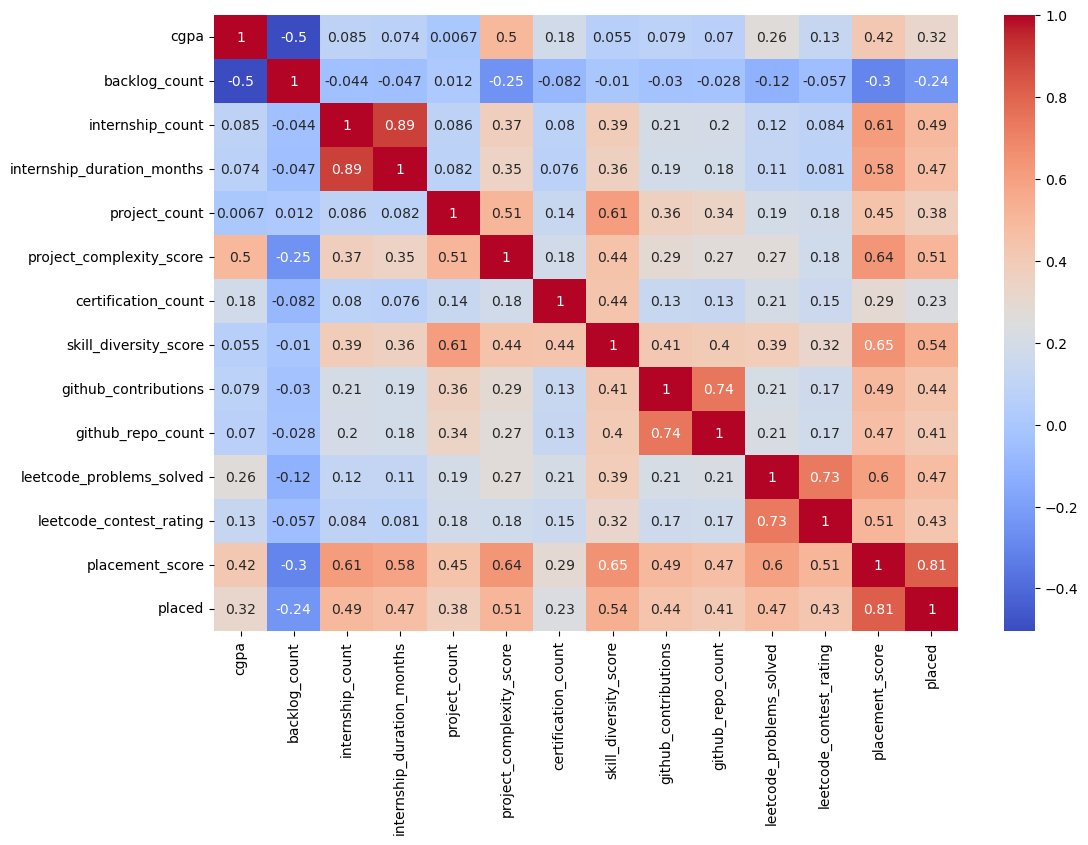

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

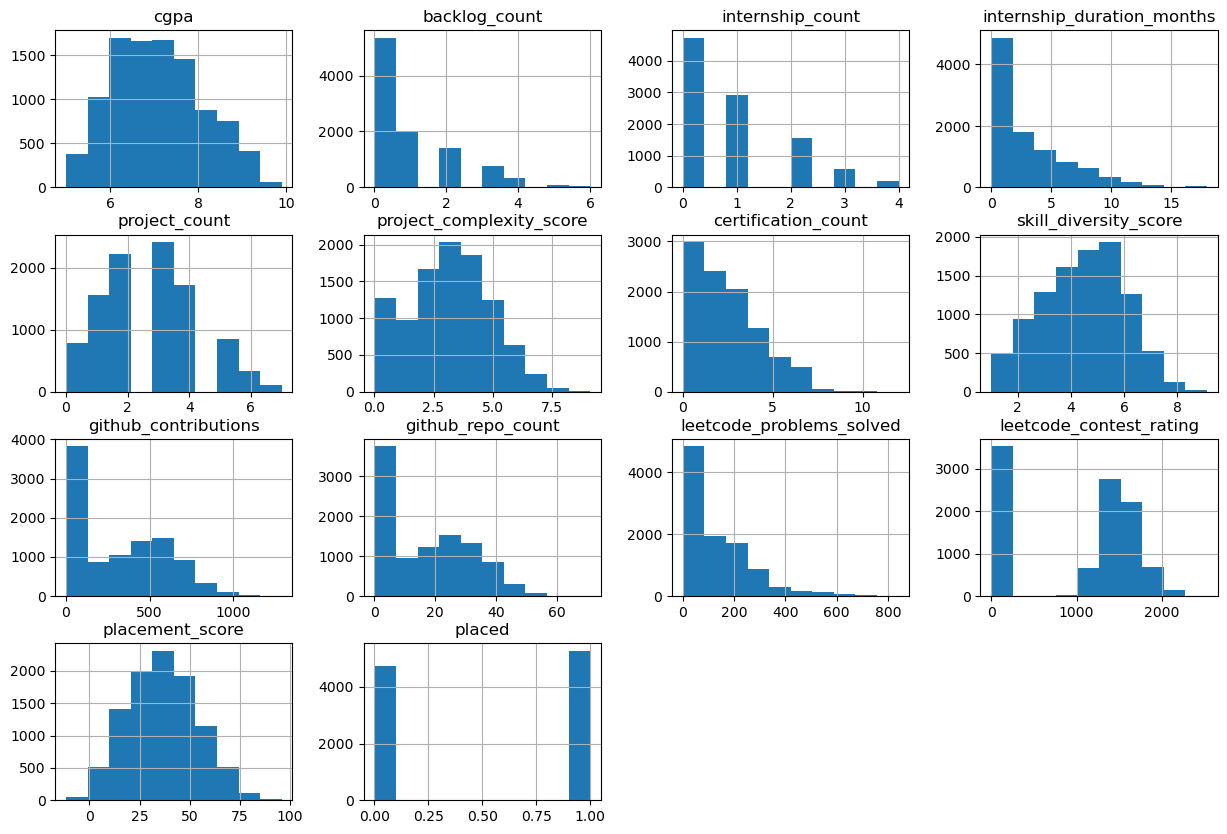

In [10]:
df.hist(figsize=(15,10))
plt.show()

<Axes: >

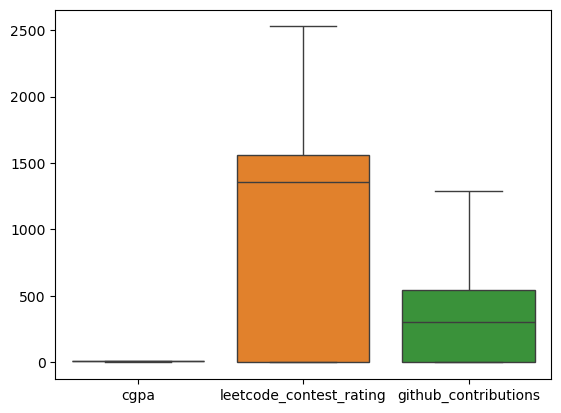

In [11]:
sns.boxplot(data=df[["cgpa","leetcode_contest_rating","github_contributions"]])